<a href="https://colab.research.google.com/github/aleksejalex/DYNR1cv_2026/blob/main/DYNR1cv_01_BayesNets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DYNR1cv - Bayesian nets.

Prepared by: *Aleksej Gaj* ([email](mailto:aleksejalex@gmail.com))

This material was inspired by the documentation of `bnlearn` library: [here](https://erdogant.github.io/bnlearn/pages/html/Examples.html#parameter-learning)


Note:
 - CPT = conditional probability distribution
 - DAG = direct acyclic graph

## installing library `bnlearn`



In [1]:
#%%capture
#!pip install --upgrade pip

In [2]:
#%%capture
#!pip install pandas --upgrade
#!pip install d3blocks --upgrade

In [3]:
#%%capture
#%!pip install bnlearn

In [4]:
%%capture
!pip install pgmpy==0.1.26
!pip install bnlearn==0.10.2

## imports (RESTART SESSION/kernel BEFORE PROCEEDING)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bnlearn as bn

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


## `sprinkler` example

**Setup:** imagine we have data observed and some prior/expert knowledge about the process (relation between nodes).

**Aim:** to create Directed Acyclic Graph (DAG) on the expert knowledge and learn the conditional proability distributions (CPDs) from data.

Code below shows how to:
 - import data
 - define graph (which reflects prior knowledge about process)
 - compute/update probabilities using data
 - plot the graph/sheme
 - make an inference (i.e. to predict)

In [6]:
df = bn.import_example('sprinkler')
df.head(4)

,Cloudy,Sprinkler,Rain,Wet_Grass
0,0,0,0,0
1,1,0,1,1
2,0,1,0,1
3,1,1,1,1


This is how dataset looks like:

In [7]:
df.describe(include='all')

,Cloudy,Sprinkler,Rain,Wet_Grass
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.512000,0.309000,0.515000,0.653000
std,0.500106,0.462312,0.500025,0.476254
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


Define the network structure. This can be based on expert knowledge. Basically we specify connection between cause and efect (future edges in DAG):

In [8]:
edges = [('Cloudy', 'Sprinkler'),
         ('Cloudy', 'Rain'),
         ('Sprinkler', 'Wet_Grass'),
         ('Rain', 'Wet_Grass')]

Make the Bayesian DAG from specified connections (edges):

In [9]:
DAG = bn.make_DAG(edges)

[bnlearn] >bayes DAG created.


Plot the DAG

[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


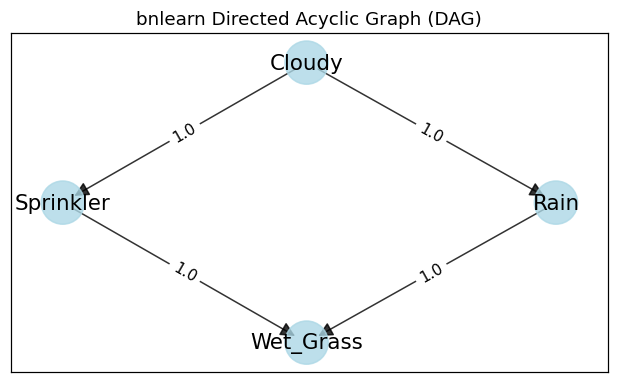

{'fig': <Figure size 770x440 with 1 Axes>,
 'ax': <Figure size 770x440 with 1 Axes>,
 'pos': {'Cloudy': (87.546, 162.0),
  'Sprinkler': (43.546, 90.0),
  'Rain': (132.55, 90.0),
  'Wet_Grass': (87.546, 18.0)},
 'G': <networkx.classes.digraph.DiGraph at 0x79aeae9e80b0>,
 'node_properties': {'Cloudy': {'node_color': '#ADD8E6', 'node_size': 800},
  'Sprinkler': {'node_color': '#ADD8E6', 'node_size': 800},
  'Rain': {'node_color': '#ADD8E6', 'node_size': 800},
  'Wet_Grass': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('Cloudy', 'Sprinkler'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Cloudy', 'Rain'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Sprinkler', 'Wet_Grass'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
   'value': np.float64(1.0)},
  ('Rain', 'Wet_Grass'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 

In [10]:
bn.plot(model=DAG, interactive=False, params_static={
            'figsize': (7, 4),
            'dpi': 110
            })

Let's do it in more beautiful way:

[10-03-2026 13:37:39] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[10-03-2026 13:37:39] [setgraphviz.setgraphviz] [INFO] The OS is not supported to automatically set Graphviz in the system env.
[10-03-2026 13:37:39] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.
[10-03-2026 13:37:39] [setgraphviz.setgraphviz] [INFO] Graphviz path found in environment.


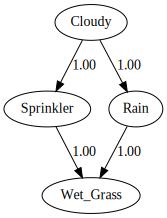

In [11]:
bn.plot_graphviz(DAG)

Parameter learning on the user-defined DAG and input data using maximum likelihood.

In [12]:
DAG = bn.parameter_learning.fit(DAG, df, methodtype='maximumlikelihood')

[bnlearn] >Parameter learning> Computing parameters using [maximumlikelihood]
[bnlearn] >CPD of Cloudy:
+-----------+-------+
| Cloudy(0) | 0.488 |
+-----------+-------+
| Cloudy(1) | 0.512 |
+-----------+-------+
[bnlearn] >CPD of Sprinkler:
+--------------+--------------------+------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)  |
+--------------+--------------------+------------+
| Sprinkler(0) | 0.4610655737704918 | 0.91015625 |
+--------------+--------------------+------------+
| Sprinkler(1) | 0.5389344262295082 | 0.08984375 |
+--------------+--------------------+------------+
[bnlearn] >CPD of Rain:
+---------+---------------------+-------------+
| Cloudy  | Cloudy(0)           | Cloudy(1)   |
+---------+---------------------+-------------+
| Rain(0) | 0.8073770491803278  | 0.177734375 |
+---------+---------------------+-------------+
| Rain(1) | 0.19262295081967212 | 0.822265625 |
+---------+---------------------+-------------+
[bnlearn] >CPD of Wet_Grass:
+----------

**How to understand these tables?** Let's understand it on the example of CPD of Sprinkler:

```
+--------------+--------------------+------------+
| Cloudy       | Cloudy(0)          | Cloudy(1)  |
+--------------+--------------------+------------+
| Sprinkler(0) | 0.4610655737704918 | 0.91015625 |
+--------------+--------------------+------------+
| Sprinkler(1) | 0.5389344262295082 | 0.08984375 |
+--------------+--------------------+------------+
```
`Cloudy` is condition, `Sprinkler` is the event of interest. Numbers represent the probability of sprinkler being in state `Sprinkler(i)` when sky is in state `Cloudy(j)`, for example:

$$   P\left( \:\text{Sprinkler(0)}\: |\: \text{Cloudy(0)} \:\right) \approx 0.46  $$



In [13]:
DAG

{'model': <pgmpy.models.BayesianNetwork.BayesianNetwork at 0x79ae564ff860>,
 'adjmat': target     Cloudy  Sprinkler   Rain  Wet_Grass
 source                                        
 Cloudy      False       True   True      False
 Sprinkler   False      False  False       True
 Rain        False      False  False       True
 Wet_Grass   False      False  False      False,
 'config': {'verbose': 3, 'method': 'maximumlikelihood', 'n_jobs': -1},
 'model_edges': [('Cloudy', 'Sprinkler'),
  ('Cloudy', 'Rain'),
  ('Sprinkler', 'Wet_Grass'),
  ('Rain', 'Wet_Grass')],
 'structure_scores': {'k2': np.float64(-1952.7499005180107),
  'bic': np.float64(-1953.219110059786),
  'bdeu': np.float64(-1954.4304910940116),
  'bds': np.float64(-1961.361962899611)},
 'independence_test': None}

Lets print the learned CPDs:

In [14]:
CPDs = bn.print_CPD(DAG)

[bnlearn] >Warning: variable(s) [None] does not exists in DAG.
[bnlearn] >Data is stored in [query.df]
+----+----------+-------+
|    |   Cloudy |     p |
+====+==========+=======+
|  0 |        0 | 0.488 |
+----+----------+-------+
|  1 |        1 | 0.512 |
+----+----------+-------+
CPD of Cloudy:
+-----------+-------+
| Cloudy(0) | 0.488 |
+-----------+-------+
| Cloudy(1) | 0.512 |
+-----------+-------+
[bnlearn] >Warning: variable(s) [None] does not exists in DAG.
[bnlearn] >Data is stored in [query.df]
+----+-------------+----------+-----------+
|    |   Sprinkler |   Cloudy |         p |
+====+=============+==========+===========+
|  0 |           0 |        0 | 0.461066  |
+----+-------------+----------+-----------+
|  1 |           0 |        1 | 0.910156  |
+----+-------------+----------+-----------+
|  2 |           1 |        0 | 0.538934  |
+----+-------------+----------+-----------+
|  3 |           1 |        1 | 0.0898438 |
+----+-------------+----------+-----------+
CPD

**Meaning of 'Independencies' output:**

`(Sprinkler ⟂ Rain | Cloudy)`: This notation indicates that the variable "Sprinkler" is conditionally independent of the variable "Rain" given the variable "Cloudy." In other words, knowing whether the sprinkler is on or off does not provide any additional information about whether it is raining, once we know the state of the "Cloudy" variable.

Lets make an inference:

In [15]:
q1 = bn.inference.fit(DAG, variables=['Wet_Grass'], evidence={'Rain':1, 'Sprinkler':0, 'Cloudy':1})

[bnlearn] >Variable Elimination.
[bnlearn] >Warning: variable(s) [None] does not exists in DAG.
[bnlearn] >Data is stored in [query.df]
+----+-------------+----------+
|    |   Wet_Grass |        p |
+====+=============+==========+
|  0 |           0 | 0.113953 |
+----+-------------+----------+
|  1 |           1 | 0.886047 |
+----+-------------+----------+


In [16]:
# !pip list

In [17]:
# !pip list >> setup_pip_312_zafungovalo_BN_2025.txt

## Bonus - structure learning

for details, see [documentation](https://erdogant.github.io/bnlearn/pages/html/Structure%20learning.html#structure-learning)

In [18]:
from tabulate import tabulate

# Load same data
df = bn.import_example('sprinkler')

Structure learning - via **Exhaustive search** (`ex`)

 - Tries all possible DAG structures.

 - Computes the score (here BIC) for each.

 - Returns the globally optimal structure according to that score.

**Pros**

 - Guaranteed optimal structure.

**Cons**

 - Computationally very expensive.

 - Practical only for very small networks (≈ ≤6–7 variables).

In [19]:
# Structure learning
model = bn.structure_learning.fit(df, methodtype='ex', scoretype='bic')

[bnlearn] >Computing best DAG using [ex]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [20]:
# Compute edge strength using chi-square independence test and remove (prune) the not-signficant edges
model = bn.independence_test(model, df, alpha=0.05, prune=True)

[bnlearn] >Compute edge strength with [chi_square]


**Conditional independence tests** for edges in the learned Bayesian network.

For each edge, it checks whether the two variables are still dependent given the other parents in the network.

Interpretation of a result:
- p-value < $\alpha = 0.05$ → dependency supported → edge is kept  
- p-value $\geq \alpha$ → independence cannot be rejected → edge may be removed

With **prune=True**, edges that are not statistically supported by the data are removed from the network.

The output table reports the tested edges together with the test statistic and p-values.

In [21]:
# Examine the output of the chi-square test
print(tabulate(model['independence_test'], tablefmt="grid", headers="keys"))

+----+-----------+-----------+-------------+-------------+--------------+-------+
|    | source    | target    | stat_test   |     p_value |   chi_square |   dof |
+====+===========+===========+=============+=============+==============+=======+
|  0 | Cloudy    | Rain      | True        | 1.08061e-87 |      394.062 |     1 |
+----+-----------+-----------+-------------+-------------+--------------+-------+
|  1 | Cloudy    | Sprinkler | True        | 8.38371e-53 |      233.906 |     1 |
+----+-----------+-----------+-------------+-------------+--------------+-------+
|  2 | Rain      | Wet_Grass | True        | 3.88651e-64 |      285.902 |     1 |
+----+-----------+-----------+-------------+-------------+--------------+-------+
|  3 | Sprinkler | Wet_Grass | True        | 1.19692e-23 |      100.478 |     1 |
+----+-----------+-----------+-------------+-------------+--------------+-------+


[bnlearn] >Set node properties.
[bnlearn]> Set edge weights based on the [chi_square] test statistic.
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Converting source-target into adjacency matrix..
[bnlearn] >Making the matrix symmetric..
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


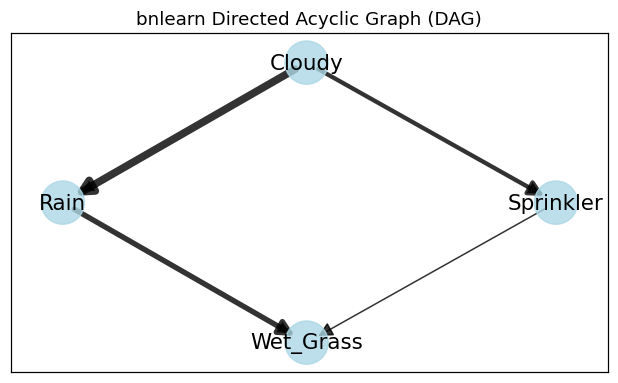

{'fig': <Figure size 770x440 with 1 Axes>,
 'ax': <Figure size 770x440 with 1 Axes>,
 'pos': {'Rain': (27.298, 90.0),
  'Wet_Grass': (71.298, 18.0),
  'Sprinkler': (116.3, 90.0),
  'Cloudy': (71.298, 162.0)},
 'G': <networkx.classes.digraph.DiGraph at 0x79ae5289ab10>,
 'node_properties': {'Cloudy': {'node_color': '#ADD8E6', 'node_size': 800},
  'Rain': {'node_color': '#ADD8E6', 'node_size': 800},
  'Sprinkler': {'node_color': '#ADD8E6', 'node_size': 800},
  'Wet_Grass': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('Rain', 'Wet_Grass'): {'color': '#000000',
   'weight': np.float64(3.5287773105152818),
   'pvalue': np.float64(63.410440075333106),
   'value': np.float64(1.0)},
  ('Sprinkler', 'Wet_Grass'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': np.float64(22.921935318719218),
   'value': np.float64(1.0)},
  ('Cloudy', 'Rain'): {'color': '#000000',
   'weight': np.float64(5.000000000000001),
   'pvalue': np.float64(86.96633272493237),
   'val

In [27]:
# Plot
bn.plot(model, edge_labels = "prob",
        params_static={
            'figsize': (7, 4),
            'dpi': 110
            }
        )